In [9]:
# Activity 1.1: Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
# Activity 1.2: Read the Dataset
df = pd.read_csv('insurance_claims.csv')

# Dataset ki shuruati 5 lines dekhna
display(df.head())

# Null values check karna
print("\nChecking for null values:")
print(df.isna().sum())

# Total null values
print("\nTotal null values in dataset:", df.isna().any().sum())

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN



Checking for null values:
months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
p

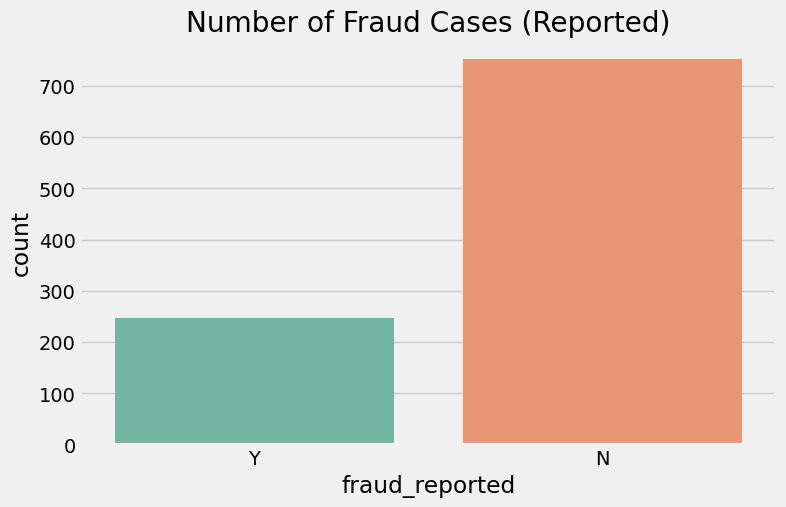

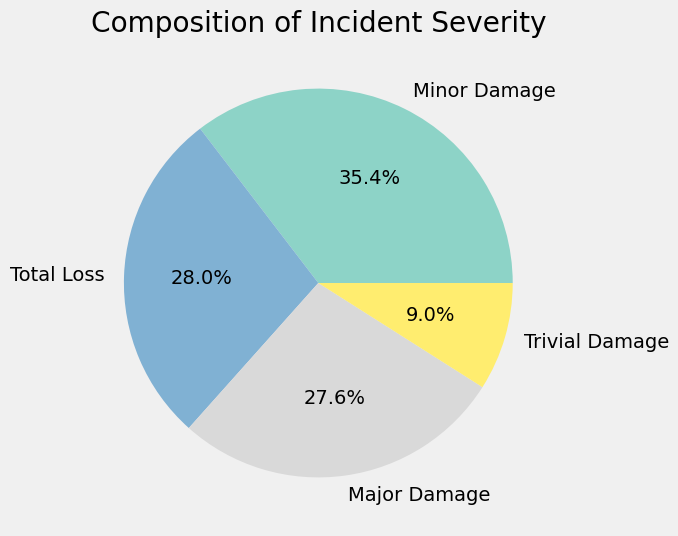

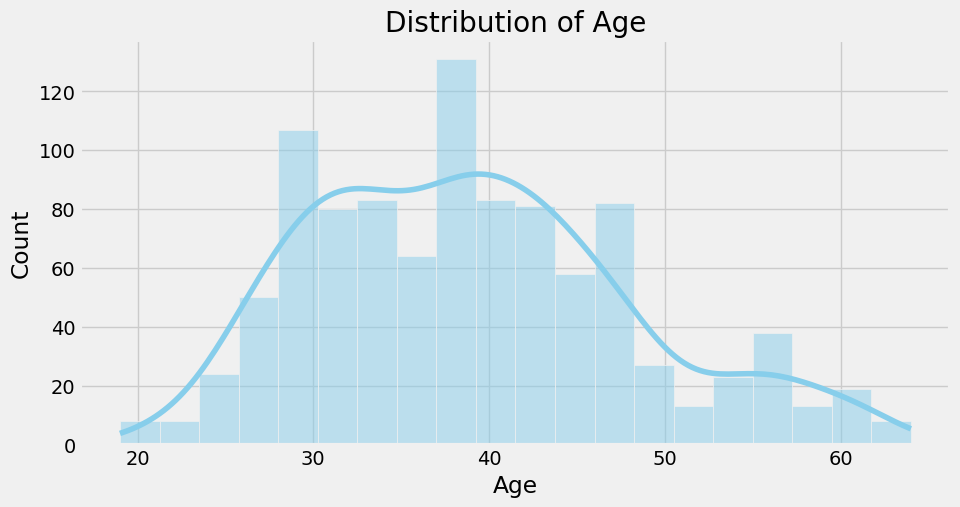

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style set karna
plt.style.use('fivethirtyeight')

# 1. Countplot for Fraud Reported (Kitne fraud cases hain)
plt.figure(figsize=(8, 5))
sns.countplot(x='fraud_reported', data=df, palette='Set2')
plt.title('Number of Fraud Cases (Reported)')
plt.show()

# 2. Pie Chart for Incident Severity (Damage kitna hua)
plt.figure(figsize=(8, 6))
df['incident_severity'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Set3')
plt.title('Composition of Incident Severity')
plt.ylabel('') # Y-axis label hatane ke liye
plt.show()

# 3. Histogram for Age Distribution (Kis age group ke claims zyada hain)
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

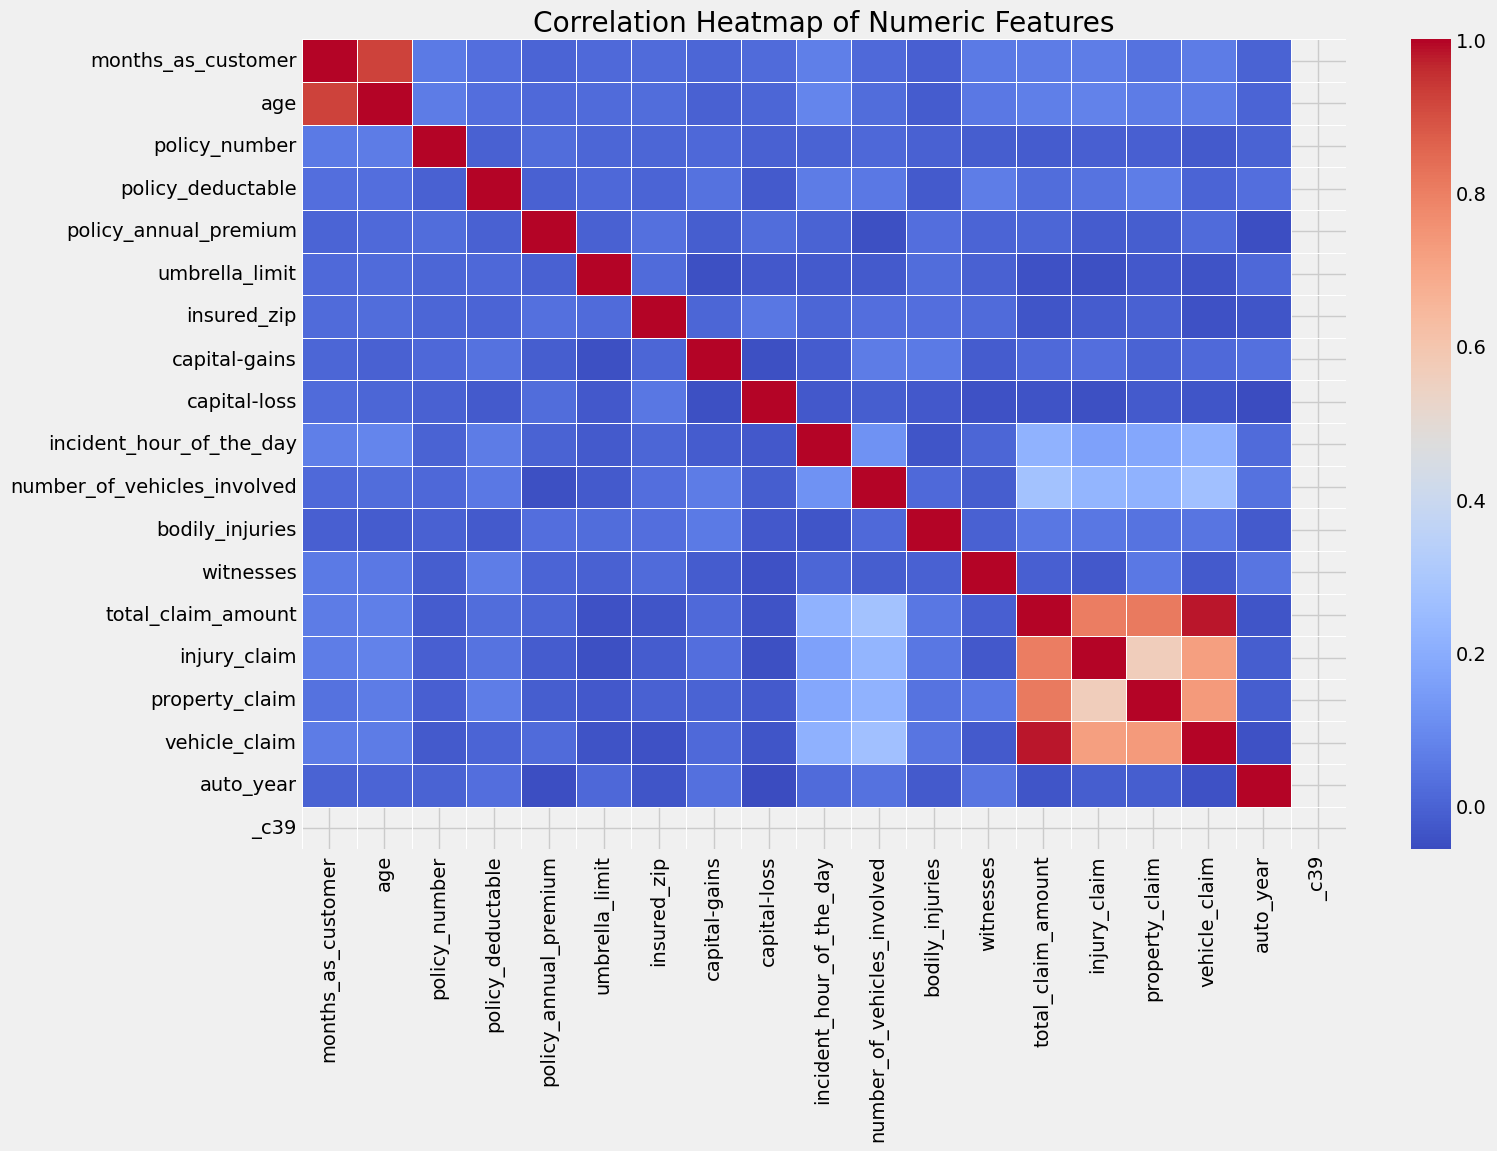

In [12]:
# Story 2.3: Multivariate Analysis (Correlation Heatmap)
plt.figure(figsize=(15, 10))
# Hum sirf numeric columns ka correlation nikal sakte hain
numeric_columns = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_columns.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [13]:
# 1. Encoding the Categorical Features
from sklearn.preprocessing import LabelEncoder

# LabelEncoder ka object banana
le = LabelEncoder()

# Wo columns dhoondhna jinme text (object/string) data hai
categorical_cols = df.select_dtypes(include=['object']).columns

# Har text column ko numbers mein convert karna
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical features successfully encoded into numbers!")

# 2. Splitting data into train and test
from sklearn.model_selection import train_test_split

# x = saare features (target ko chhod kar)
# y = target variable (humein kya predict karna hai? 'fraud_reported')
x = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

# Data ko 80% training aur 20% testing mein split karna
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("\nData Split Successful!")
print(f"Training data shape (x_train): {x_train.shape}")
print(f"Testing data shape (x_test): {x_test.shape}")

Categorical features successfully encoded into numbers!

Data Split Successful!
Training data shape (x_train): (800, 39)
Testing data shape (x_test): (200, 39)


In [14]:
# Fixing the 'nan' issue

# 1. Jo bhi column poori tarah khali hai (jaise _c39), usko drop kar dete hain
df = df.dropna(axis=1)

# 2. Wapas se x aur y banate hain
x = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

# 3. Wapas se Data Split karte hain
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 4. Wapas se Scaling karte hain
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

print("Data Scaling fixed! No more 'nan'.")
print(f"Scaled x_train (first row): {x_train[0]}")

Data Scaling fixed! No more 'nan'.
Scaled x_train (first row): [ 0.30141859  0.64266744  0.18103599  1.6491045  -1.20645802  1.27071707
  1.39991138 -0.61519124 -0.48930152 -0.9564003  -0.93698147  1.59468037
 -0.1559634  -1.51999663  0.91525747 -0.90544031  0.96926524  0.89352024
  0.74418307  0.31063037 -0.21317446  0.90174294  0.35142607  0.49309378
 -1.27978393 -0.94995018 -0.80469546  0.06721954  1.21942152  0.46537425
  0.00777487  1.44736187  1.33592487  1.37540887  1.32765371 -1.60219405
  1.23443735  1.00849147]
